# ЛР №3 — Згорткові нейронні мережі
CIFAR-10 · ResNet18 backbone · FFT-based convolution

In [1]:
import sys, os, time, copy, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import label_binarize

from models import build_model_a, build_model_b, count_trainable, count_total

SEED       = 42
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 10
BATCH_SIZE  = 128
EPOCHS      = 10
OUT_DIR     = 'output'
os.makedirs(OUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed()
print(f'Device: {DEVICE}')
print(f'CUDA: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

Device: cuda
CUDA: NVIDIA GeForce RTX 3070


## 1. Data — CIFAR-10

In [2]:
# ResNet expects 224×224; CIFAR-10 is 32×32 → upsample
train_tf = transforms.Compose([
    transforms.Resize(64),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(64, padding=4),
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465],
                         [0.2470, 0.2435, 0.2616]),
])
val_tf = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465],
                         [0.2470, 0.2435, 0.2616]),
])

train_ds = datasets.CIFAR10('data', train=True,  download=True, transform=train_tf)
val_ds   = datasets.CIFAR10('data', train=False, download=True, transform=val_tf)

g = torch.Generator(); g.manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

CLASSES = train_ds.classes
print('Classes:', CLASSES)
print(f'Train: {len(train_ds)}  Val: {len(val_ds)}')

100.0%


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 50000  Val: 10000


## 2. Model inspection

In [3]:
set_seed()
model_a = build_model_a(NUM_CLASSES).to(DEVICE)
set_seed()
model_b = build_model_b(NUM_CLASSES).to(DEVICE)

print('=== Model A (spatial conv) ===')
print(f'  Trainable params : {count_trainable(model_a):,}')
print(f'  Total params     : {count_total(model_a):,}')
print()
print('=== Model B (FFT conv) ===')
print(f'  Trainable params : {count_trainable(model_b):,}')
print(f'  Total params     : {count_total(model_b):,}')
print()
print('Model B — first conv layer:')
print(model_b.conv1)

=== Model A (spatial conv) ===
  Trainable params : 5,130
  Total params     : 11,181,642

=== Model B (FFT conv) ===
  Trainable params : 5,130
  Total params     : 11,024,778

Model B — first conv layer:
FFTConv2d()


## 3. Training loop

In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    all_probs, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        n += x.size(0)
        all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        all_labels.append(y.cpu().numpy())
    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    return total_loss / n, correct / n, probs, labels


def train(model, name, epochs=EPOCHS, lr=1e-3):
    set_seed()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'epoch_time':[]}
    best_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        t0 = time.perf_counter()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        elapsed = time.perf_counter() - t0
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(elapsed)

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(f'[{name}] Epoch {epoch:2d}/{epochs}  '
              f'loss={tr_loss:.4f}/{val_loss:.4f}  '
              f'acc={tr_acc:.3f}/{val_acc:.3f}  '
              f't={elapsed:.1f}s')

    model.load_state_dict(best_state)
    return history

In [5]:
print('Training Model A (spatial conv)...')
hist_a = train(model_a, 'A')

Training Model A (spatial conv)...
[A] Epoch  1/10  loss=1.6241/1.3756  acc=0.439/0.533  t=4.8s
[A] Epoch  2/10  loss=1.4417/1.3403  acc=0.504/0.549  t=4.0s
[A] Epoch  3/10  loss=1.4295/1.3062  acc=0.507/0.560  t=4.2s
[A] Epoch  4/10  loss=1.4249/1.3091  acc=0.509/0.557  t=3.9s
[A] Epoch  5/10  loss=1.4148/1.2957  acc=0.512/0.559  t=3.9s
[A] Epoch  6/10  loss=1.4016/1.2849  acc=0.519/0.569  t=3.9s
[A] Epoch  7/10  loss=1.3945/1.2890  acc=0.522/0.566  t=3.9s
[A] Epoch  8/10  loss=1.3946/1.2831  acc=0.519/0.563  t=4.4s
[A] Epoch  9/10  loss=1.3842/1.2811  acc=0.523/0.567  t=4.4s
[A] Epoch 10/10  loss=1.3737/1.2831  acc=0.527/0.568  t=4.3s


In [6]:
print('Training Model B (FFT conv)...')
hist_b = train(model_b, 'B')

Training Model B (FFT conv)...
[B] Epoch  1/10  loss=1.8768/1.6383  acc=0.325/0.419  t=41.1s
[B] Epoch  2/10  loss=1.7274/1.5883  acc=0.385/0.439  t=40.3s
[B] Epoch  3/10  loss=1.7196/1.5799  acc=0.390/0.441  t=33.7s
[B] Epoch  4/10  loss=1.7079/1.5797  acc=0.393/0.444  t=33.8s
[B] Epoch  5/10  loss=1.7036/1.5666  acc=0.397/0.446  t=33.7s
[B] Epoch  6/10  loss=1.6965/1.5679  acc=0.399/0.450  t=33.8s
[B] Epoch  7/10  loss=1.6928/1.5555  acc=0.398/0.456  t=33.7s
[B] Epoch  8/10  loss=1.6809/1.5497  acc=0.402/0.456  t=33.8s
[B] Epoch  9/10  loss=1.6765/1.5491  acc=0.403/0.461  t=33.7s
[B] Epoch 10/10  loss=1.6774/1.5472  acc=0.403/0.463  t=33.7s


## 4. Metrics — ROC-AUC, F1, MAPE

In [7]:
def compute_metrics(model, loader, name):
    set_seed()  # fixed seed for transparency
    criterion = nn.CrossEntropyLoss()
    _, acc, probs, labels = evaluate(model, loader, criterion, DEVICE)

    # ROC-AUC (one-vs-rest, macro)
    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    roc_auc = roc_auc_score(labels_bin, probs, multi_class='ovr', average='macro')

    # F1-score (weighted)
    preds = probs.argmax(axis=1)
    f1 = f1_score(labels, preds, average='weighted')

    # MAPE — mean absolute percentage error between probs and one-hot targets
    one_hot = labels_bin.astype(np.float32)
    # avoid division by zero: only compute where target > 0
    mask = one_hot > 0
    mape = np.mean(np.abs(one_hot[mask] - probs[mask]) / (one_hot[mask] + 1e-8)) * 100

    print(f'=== {name} ===')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  ROC-AUC  : {roc_auc:.4f}')
    print(f'  F1-score : {f1:.4f}')
    print(f'  MAPE     : {mape:.2f}%')
    return dict(acc=acc, roc_auc=roc_auc, f1=f1, mape=mape)

metrics_a = compute_metrics(model_a, val_loader, 'Model A (spatial)')
print()
metrics_b = compute_metrics(model_b, val_loader, 'Model B (FFT)')

=== Model A (spatial) ===
  Accuracy : 0.5685
  ROC-AUC  : 0.9046
  F1-score : 0.5655
  MAPE     : 59.95%

=== Model B (FFT) ===
  Accuracy : 0.4625
  ROC-AUC  : 0.8598
  F1-score : 0.4615
  MAPE     : 71.05%


## 5. Learning curves & speed comparison

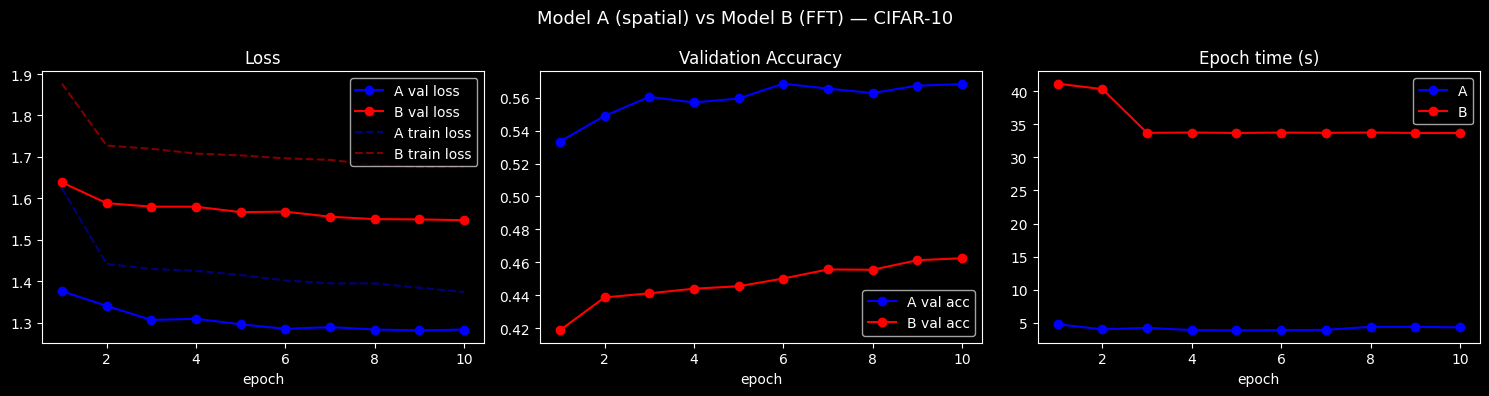

Avg epoch time  A: 4.2s  B: 35.1s


In [8]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Model A (spatial) vs Model B (FFT) — CIFAR-10', fontsize=13)

# Loss
axes[0].plot(epochs_range, hist_a['val_loss'], 'b-o', label='A val loss')
axes[0].plot(epochs_range, hist_b['val_loss'], 'r-o', label='B val loss')
axes[0].plot(epochs_range, hist_a['train_loss'], 'b--', alpha=0.5, label='A train loss')
axes[0].plot(epochs_range, hist_b['train_loss'], 'r--', alpha=0.5, label='B train loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('epoch')

# Accuracy
axes[1].plot(epochs_range, hist_a['val_acc'], 'b-o', label='A val acc')
axes[1].plot(epochs_range, hist_b['val_acc'], 'r-o', label='B val acc')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].set_xlabel('epoch')

# Epoch time
axes[2].plot(epochs_range, hist_a['epoch_time'], 'b-o', label='A')
axes[2].plot(epochs_range, hist_b['epoch_time'], 'r-o', label='B')
axes[2].set_title('Epoch time (s)'); axes[2].legend(); axes[2].set_xlabel('epoch')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/training_curves.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Avg epoch time  A: {np.mean(hist_a["epoch_time"]):.1f}s  B: {np.mean(hist_b["epoch_time"]):.1f}s')

## 6. Filter size speed benchmark (small vs large kernels)

k= 3  spatial=  0.55ms  FFT= 17.01ms  ratio=30.89x
k= 5  spatial=  1.54ms  FFT= 16.89ms  ratio=10.98x
k= 7  spatial=  2.77ms  FFT= 16.98ms  ratio=6.14x
k=11  spatial=  7.36ms  FFT= 15.53ms  ratio=2.11x
k=15  spatial= 12.70ms  FFT= 16.06ms  ratio=1.26x
k=21  spatial= 24.54ms  FFT= 14.88ms  ratio=0.61x
k=31  spatial= 50.80ms  FFT= 15.00ms  ratio=0.30x


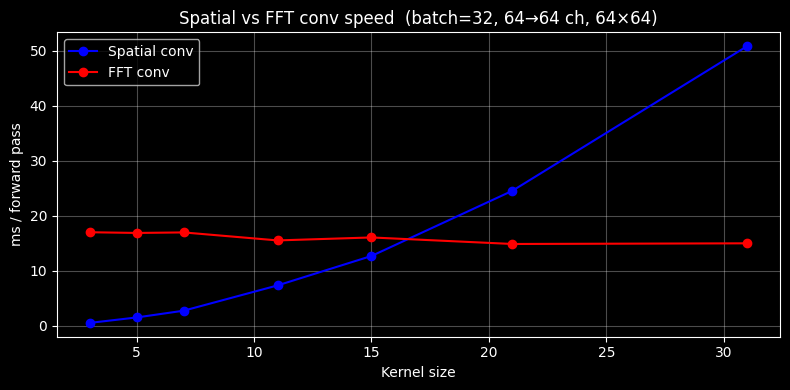

In [9]:
import torch.nn as nn
from fft_conv import FFTConv2d

def bench_conv(layer, x, n_iter=50):
    layer = layer.to(DEVICE)
    x = x.to(DEVICE)
    # warm-up
    with torch.no_grad():
        for _ in range(5):
            _ = layer(x)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_iter):
            _ = layer(x)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n_iter * 1000  # ms per forward pass


IN_CH, OUT_CH = 64, 64
IMG_SIZE = 64
BATCH = 32
x_bench = torch.randn(BATCH, IN_CH, IMG_SIZE, IMG_SIZE)

kernel_sizes = [3, 5, 7, 11, 15, 21, 31]
times_spatial, times_fft = [], []

for k in kernel_sizes:
    pad = k // 2
    conv  = nn.Conv2d(IN_CH, OUT_CH, k, padding=pad, bias=False)
    fconv = FFTConv2d(IN_CH, OUT_CH, k, bias=False)
    ts = bench_conv(conv,  x_bench)
    tf = bench_conv(fconv, x_bench)
    times_spatial.append(ts)
    times_fft.append(tf)
    print(f'k={k:2d}  spatial={ts:6.2f}ms  FFT={tf:6.2f}ms  ratio={tf/ts:.2f}x')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(kernel_sizes, times_spatial, 'b-o', label='Spatial conv')
ax.plot(kernel_sizes, times_fft,    'r-o', label='FFT conv')
ax.set_xlabel('Kernel size'); ax.set_ylabel('ms / forward pass')
ax.set_title(f'Spatial vs FFT conv speed  (batch={BATCH}, {IN_CH}→{OUT_CH} ch, {IMG_SIZE}×{IMG_SIZE})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/speed_benchmark.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Summary table

In [10]:
import pandas as pd

rows = []
for name, m, h in [('Model A (spatial)', metrics_a, hist_a),
                    ('Model B (FFT)',     metrics_b, hist_b)]:
    rows.append({
        'Model'   : name,
        'Accuracy': f"{m['acc']:.4f}",
        'ROC-AUC' : f"{m['roc_auc']:.4f}",
        'F1'      : f"{m['f1']:.4f}",
        'MAPE %'  : f"{m['mape']:.2f}",
        'Avg epoch (s)': f"{np.mean(h['epoch_time']):.1f}",
    })

df = pd.DataFrame(rows).set_index('Model')
display(df)

,Accuracy,ROC-AUC,F1,MAPE %,Avg epoch (s)
Model,,,,,
Model A (spatial),0.5685,0.9046,0.5655,59.95,4.2
Model B (FFT),0.4625,0.8598,0.4615,71.05,35.1
